# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Noah Demmenie
* Username: ndemmenie
* Student number: S6294588
* Group (AS1, etc.): AS3

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import numpy as np
from numpy import sin
import sympy as sp
from scipy.integrate import quad

class Integration:
    def __init__(self, func, a, b):
        self.func = func
        self.a = a
        self.b = b
        
    def f(self, x):
        return eval(self.func)

    def trapezium(self):
        return (self.b - self.a) * (self.f(self.a) + self.f(self.b)) / 2

    def simpson(self, n = 1000):
        if n % 2 != 0:
            n += 1
        
        h = (self.b - self.a) / n
        x = np.linspace(self.a, self.b, n + 1)
        y = self.f(x)

        return (h/3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])

    def monte_carlo(self, n = 10000):
        x = np.random.uniform(self.a, self.b, n)
        y = self.f(x)
        return ((self.b - self.a) / n) * np.sum(y)

    def sympy_integral(self):
        x = sp.symbols("x")
        expr = sp.sympify(self.func)
        result = sp.integrate(expr, (x, self.a, self.b))
        return float(result)

    def scipy_integral(self):
        result = quad(self.f, self.a, self.b)
        return result[0]

f = "1 + x + sin(2 * x)"

a = 0.5
b = 3.0

integral = Integration(f, a, b)

print(f"Trapezium integral = {integral.trapezium()}")
print(f"Simpson integral = {integral.simpson()}")
print(f"Monte carlo integral = {integral.monte_carlo()}")
print(f"Sympy integral = {integral.sympy_integral()}")
print(f"Scipy integral = {integral.scipy_integral()}")

Trapezium integral = 7.577569358261213
Simpson integral = 6.665066009608158
Monte carlo integral = 6.6656470930956
Sympy integral = 6.665066009608887
Scipy integral = 6.6650660096088865


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

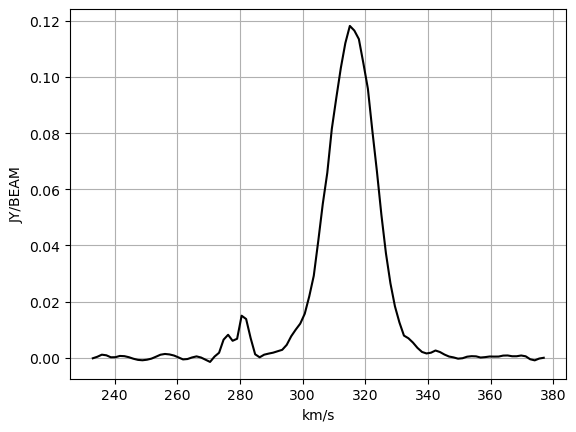

In [4]:
import numpy as np
from astropy.io import fits
from matplotlib.pyplot import show, subplots

# Open and define data

hdulist = fits.open("ngc6946.fits")
data = hdulist[0].data
header = hdulist[0].header
data_array = np.asarray(data, dtype = float)

profile = data_array[:, 55, 58]
velocity = np.linspace(233, 377, len(profile))

# Plot everything

fig, ax = subplots()
ax.plot(velocity, profile, color = "k")
ax.set_xlabel(header['CUNIT3'])
ax.set_ylabel(header['BUNIT'])
ax.grid()
show()

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [6]:
def f(x, amp, mu, sigma, zero):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) + zero

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [8]:
import sympy as sp

# Make everything sympy symbols

x = sp.symbols("x")
amp = sp.symbols("amp")
mu = sp.symbols("mu")
sigma = sp.symbols("sigma")
zero = sp.symbols("zero")

# Define function

func = amp * sp.exp(-((x - mu)**2) / (2 * sigma**2)) + zero

# Compute derivatives

damp= sp.diff(func, amp)
dmu = sp.diff(func, mu)
dsigma = sp.diff(func, sigma)

print(f"Derivative wrt amp = {damp}")
print(f"Derivative wrt mu = {dmu}")
print(f"Derivative wrt sigma = {dsigma}")

Derivative wrt amp = exp(-(-mu + x)**2/(2*sigma**2))
Derivative wrt mu = -amp*(2*mu - 2*x)*exp(-(-mu + x)**2/(2*sigma**2))/(2*sigma**2)
Derivative wrt sigma = amp*(-mu + x)**2*exp(-(-mu + x)**2/(2*sigma**2))/sigma**3


**The derivatives with respect to mu and sigma contain exponential and non-linear terms. Therefore, the model is non-linear in its parameters.**

In [9]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [10]:
import numpy as np
from astropy.io import fits
from matplotlib.pyplot import subplots, show
from scipy.optimize import curve_fit

# Compute initial estimates

zero0 = profile.min()
amp0 = profile.max() - profile.min()
mu0 = velocity[np.argmax(profile)]
sigma0 = 10

# Compute best fit parameters

p0 = (amp0, mu0, sigma0, zero0)
print(f"Initial estimates: (amp = {amp0:.4f}, mu = {mu0:.4f}, sigma = {sigma0:.4f}, zero = {zero0:.4f})")
beta, pcov = curve_fit(f, velocity, profile, p0 = p0)

dbeta = np.sqrt(np.diag(pcov))

print("\nBest fit parameters:")
print(f"amp = {beta[0]:.4f} ± {dbeta[0]:.4f}")
print(f"mu = {beta[1]:.4f} ± {dbeta[1]:.4f}")
print(f"sigma = {beta[2]:.4f} ± {dbeta[2]:.4f}")
print(f"zero = {beta[3]:.4f} ± {dbeta[3]:.4f}")

Initial estimates: (amp = 0.1197, mu = 315.0800, sigma = 10.0000, zero = -0.0015)

Best fit parameters:
amp = 0.1169 ± 0.0011
mu = 315.7168 ± 0.0772
sigma = 7.2611 ± 0.0817
zero = 0.0013 ± 0.0003


**Zero is chosen as the minimum of the profile because it represents the background level. Amp is taken as max - min because it represents the peak height above the background. Mu is chosen at the maximum of the profile because its the center of the peak. Sigma is chosen as ~10 because it represents the width of the peak and this is a reasonable estimate from the spread of the data.**

In [11]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

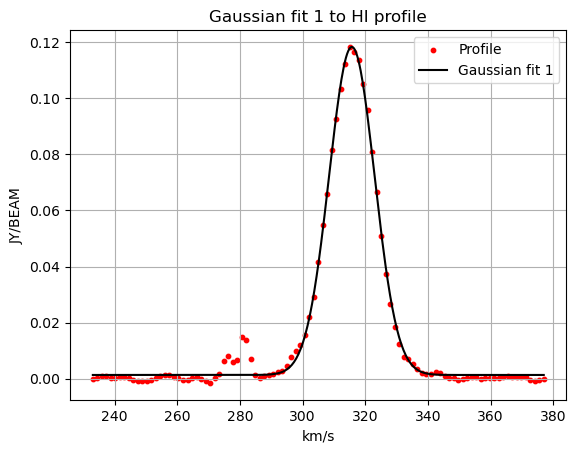

In [12]:
X = np.linspace(np.min(velocity), np.max(velocity), 400)
fig, ax = subplots()
ax.scatter(velocity, profile, label = "Profile", s = 10, color = "r")
ax.plot(X, f(X, *beta), label = "Gaussian fit 1", color = "k")
ax.set_xlabel(header["CUNIT3"])
ax.set_ylabel(header["BUNIT"])
ax.set_title("Gaussian fit 1 to HI profile")
ax.legend()
ax.grid()
show()

In [13]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

Initial estimates: (amp1 = 0.120, mu1 = 315.080, signa1 = 10.000, amp2 = 0.015, mu2 = 281.000, sigma2 = 3.000, zero = -0.001)
Best fit parameters
amp1 = 0.118 ± 0.001
mu1 = 315.715 ± 0.044
sigma1 = 7.335 ± 0.047
amp2 = 0.012 ± 0.001
mu2 = 280.247 ± 0.282
sigma2 = 3.022 ± 0.290
zero = 0.001 ± 0.000


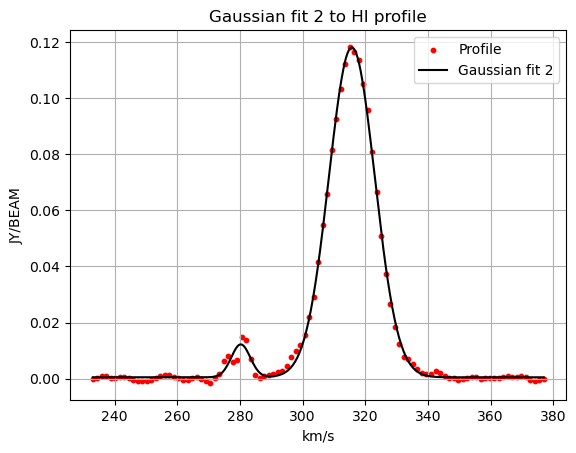

In [14]:
def f2(x, amp1, mu1, sigma1, amp2, mu2, sigma2, zero):
    g1 = amp1 * np.exp(-((x - mu1)**2) / (2 * sigma1**2))
    g2 = amp2 * np.exp(-((x - mu2)**2) / (2 * sigma2**2))
    return g1 + g2 + zero

# Compute initial estimates for second signal

amp02 = 0.015
mu02 = 281
sigma02 = 3

p02 = (amp0, mu0, sigma0, amp02, mu02, sigma02, zero0)
print(f"Initial estimates: (amp1 = {amp0:.3f}, mu1 = {mu0:.3f}, signa1 = {sigma0:.3f}, amp2 = {amp02:.3f}, mu2 = {mu02:.3f}, sigma2 = {sigma02:.3f}, zero = {zero0:.3f})")

# Compute best fit parameters

beta2, pcov2 = curve_fit(f2, velocity, profile, p0 = p02)

dbeta2 = np.sqrt(np.diag(pcov2))

print("Best fit parameters")
print(f"amp1 = {beta2[0]:.3f} ± {dbeta2[0]:.3f}")
print(f"mu1 = {beta2[1]:.3f} ± {dbeta2[1]:.3f}")
print(f"sigma1 = {beta2[2]:.3f} ± {dbeta2[2]:.3f}")
print(f"amp2 = {beta2[3]:.3f} ± {dbeta2[3]:.3f}")
print(f"mu2 = {beta2[4]:.3f} ± {dbeta2[4]:.3f}")
print(f"sigma2 = {beta2[5]:.3f} ± {dbeta2[5]:.3f}")
print(f"zero = {beta2[6]:.3f} ± {dbeta2[6]:.3f}")

# Plot everything

fig, ax = subplots()
ax.scatter(velocity, profile, label = "Profile", s = 10, color = "r")
ax.plot(X, f2(X, *beta2), label = "Gaussian fit 2", color = "k")
ax.set_xlabel(header["CUNIT3"])
ax.set_ylabel(header["BUNIT"])
ax.set_title("Gaussian fit 2 to HI profile")
ax.legend()
ax.grid()
show()

For the initial parameters for the second signal, I just looked very carefully at the plot and made an estimation for all parameters.

In [15]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [16]:
factor = 2 * np.sqrt(2 * np.log(2))

FWHM1 = factor * beta2[2]
dFWHM1 = factor * dbeta2[2]

FWHM2 = factor * beta2[5]
dFWHM2 = factor * dbeta2[5]

print(f"FWHM main signal = {FWHM1:.3f} ± {dFWHM1:.3f} {header['CUNIT3']}")
print(f"FWHM second signal = {FWHM2:.3f} ± {dFWHM2:.3f} {header['CUNIT3']}")

FWHM main signal = 17.272 ± 0.110 km/s
FWHM second signal = 7.115 ± 0.684 km/s


In [17]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

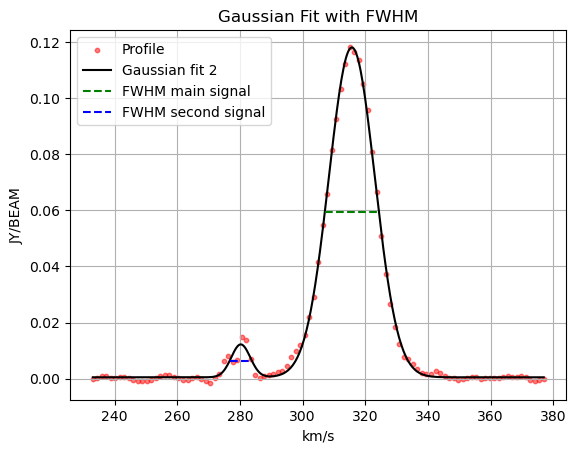

In [18]:
# Define every parameter

mu1 = beta2[1]
mu2 = beta2[4]
amp1 = beta2[0]
amp2 = beta2[3]
zero = beta2[6]

# Compute center of fitted peak

y1 = zero + amp1 / 2
y2 = zero + amp2 / 2

# Plot everything

fig, ax = subplots()
ax.scatter(velocity, profile, label = "Profile", s = 10, color = "r", alpha = 0.5)
ax.plot(X, f2(X, *beta2), label = "Gaussian fit 2", color = "k")
ax.hlines(y1, mu1 - FWHM1 / 2, mu1 + FWHM1/2, linestyles = "--", label = "FWHM main signal", color = "g")
ax.hlines(y2, mu2 - FWHM2 / 2, mu2 + FWHM2/2, linestyles = "--", label = "FWHM second signal", color = "b")
ax.set_xlabel(header["CUNIT3"])
ax.set_ylabel(header["BUNIT"])
ax.set_title("Gaussian Fit with FWHM")
ax.legend()
ax.grid()
show()

In [19]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   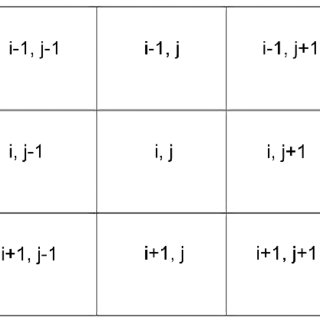    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

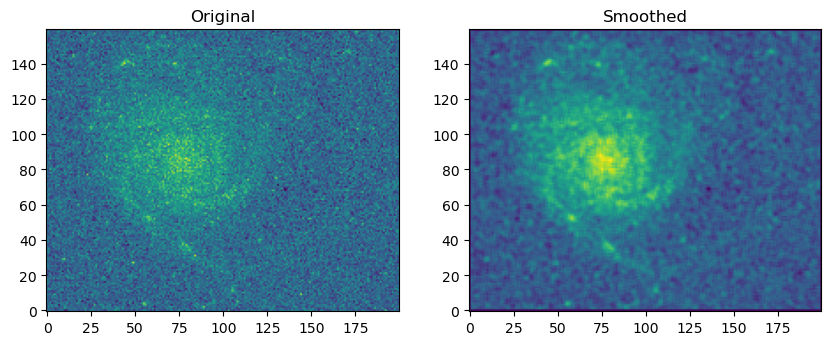

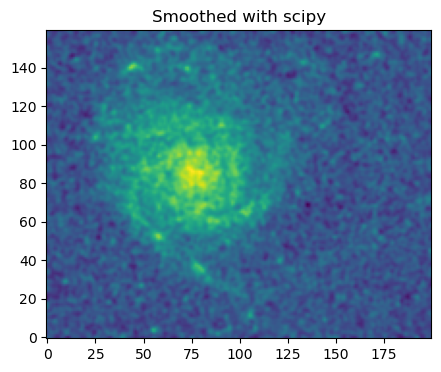

In [20]:
import numpy as np
from astropy.io import fits
from matplotlib.pyplot import subplots, show
from scipy import ndimage

# Open and define data

hdulist = fits.open("faintgalaxy.fits")
data = hdulist[0].data
data_array = np.asarray(data, dtype = float)

# Define smooth function and put the function on the data

def smooth(M):
    ny = M.shape[0]
    nx = M.shape[1]
    Mc = np.zeros_like(M)
    
    for y in range (1, ny-1):
        for x in range(1, nx-1):
            block = M[y-1:y+2, x-1:x+2]
            Mc[y, x] = np.mean(block)
    
    return Mc

Mc1 = smooth(data_array)

# Plot everything

fig, ax = subplots(1, 2, figsize = (10, 4))
ax[0].imshow(data_array, origin='lower')
ax[0].set_title("Original")
ax[1].imshow(Mc1, origin='lower')
ax[1].set_title("Smoothed")
show()

# Define scipy smooth function and put the function on the data

def smooth2(M):
    Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
    return Mc

Mc2 = smooth2(data_array)

# Plot the image

fig, ax = subplots(figsize = (10, 4))
ax.imshow(Mc2, origin='lower')
ax.set_title("Smoothed with scipy")
show()

# I don't know if the exercise want the scipy smoothed to be in the same mosaic plot, I assumed it did not, because it just said "plot" and nothing else. 

In [21]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [22]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 25. Student score: 0.0.  Task Grade = 0.0
